In [1]:
PATH_FOR_DATA_SET = '../data/raw/kaggle_delhi_ncr_aqi_dataset.csv';

In [2]:
import pandas as pd

df = pd.read_csv(PATH_FOR_DATA_SET)

print("=" * 50)
print("  Dataset Overview")
print("=" * 50)
print(f"  Train shape: {df.shape}  (rows, cols)")
print()
print("  First 5 rows of data:")
print(df.head().to_string())

  Dataset Overview
  Train shape: (201664, 25)  (rows, cols)

  First 5 rows of data:
              datetime        date  year  month  day  hour day_of_week  is_weekend  season   city              station  latitude  longitude   pm25   pm10    no2   so2    co    o3  temperature  humidity  wind_speed  visibility  aqi aqi_category
0  2020-01-01 06:00:00  2020-01-01  2020      1    1     6   Wednesday           0  winter  Delhi   Anand Vihar, Delhi   28.6469    77.3164  371.8  739.4  119.6  47.7  5.19  12.3          9.4       100         3.6         1.2  500       Severe
1  2020-01-01 12:00:00  2020-01-01  2020      1    1    12   Wednesday           0  winter  Delhi   Anand Vihar, Delhi   28.6469    77.3164  301.1  588.8  117.9  39.3  4.32  15.8         20.6        50         5.9         1.4  500       Severe
2  2020-01-01 18:00:00  2020-01-01  2020      1    1    18   Wednesday           0  winter  Delhi   Anand Vihar, Delhi   28.6469    77.3164  334.0  602.6  150.1  36.3  7.13  14.3    

In [3]:
# Date Range

print(df['date'].min())
print(df['date'].max())

2020-01-01
2025-12-31


Mode = 500
Median = 232
Mean = 266
45355
22.49038003808315
  Raw skewness:  0.1931
  Log skewness:  -0.4903  ← much better


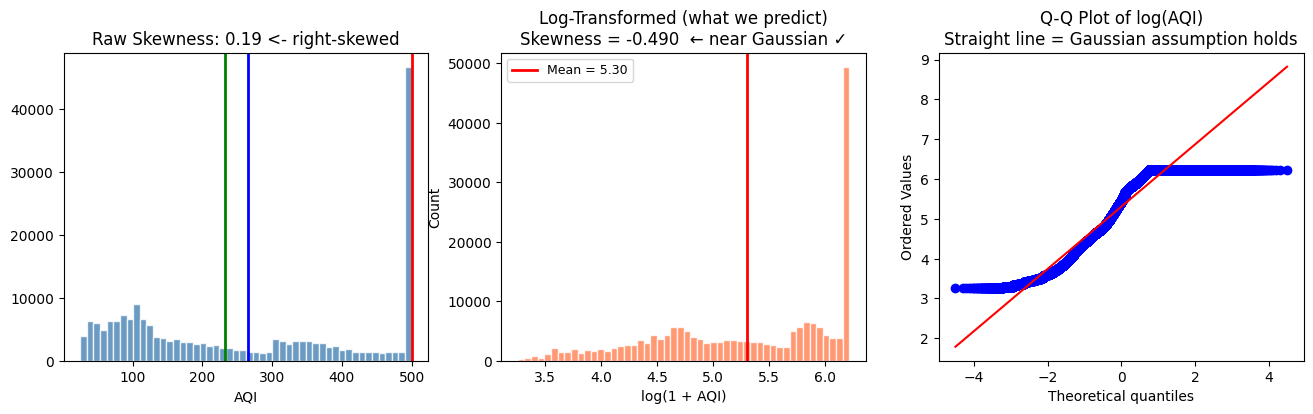

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

_, axes = plt.subplots(1, 3, figsize=(16, 4))

mode_aqi = df['aqi'].mode()[0]
median_aqi = df['aqi'].median()
mean_aqi = df['aqi'].mean()

# Raw distribution
axes[0].hist(df['aqi'], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Raw Distribution')
axes[0].axvline(mode_aqi, color='red', lw=2, label=f"Mode = ${mode_aqi:.0f}k")
axes[0].axvline(median_aqi, color='green', lw=2, label=f"Median = ${median_aqi:.0f}k")
axes[0].axvline(mean_aqi, color='blue', lw=2, label=f"Mean = ${mean_aqi:.0f}k")
axes[0].set_xlabel('AQI')
skew_raw = df['aqi'].skew()
axes[0].set_title(f"Raw Skewness: {skew_raw:.2f} <- {'left-skewed' if skew_raw < 0 else 'right-skewed'}")

print(f"Mode = {mode_aqi:.0f}")
print(f"Median = {median_aqi:.0f}")
print(f"Mean = {mean_aqi:.0f}")

# 500 mode AQI is a problem we need to check if it is a data entry error
print((df['aqi'] == 500).sum())
# if % < 5 means low, data is not capped (move on)
# if % > 20 means high, data is capped
print((df['aqi'] == 500).sum() / len(df) * 100)

# as we have more than 20% of data as 500
# This adds a binary feature telling the model "this reading hit the sensor ceiling."
df['aqi_capped'] = (df['aqi'] == 500).astype(int)

# Log-transformed — this is what we'll actually predict
log_price = np.log1p(df['aqi'])
axes[1].hist(log_price, bins=50, color='coral', alpha=0.8, edgecolor='white')
axes[1].axvline(log_price.mean(), color='red', lw=2, label=f'Mean = {log_price.mean():.2f}')
axes[1].set_xlabel('log(1 + AQI)')
axes[1].set_ylabel('Count')
skew_log = log_price.skew()
axes[1].set_title(f'Log-Transformed (what we predict)\nSkewness = {skew_log:.3f}  ← near Gaussian ✓')
axes[1].legend(fontsize=9)

# Q-Q plot of log price (should follow straight line if Gaussian)
stats.probplot(log_price, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of log(AQI)\nStraight line = Gaussian assumption holds')

print(f"  Raw skewness:  {skew_raw:.4f}")
print(f"  Log skewness:  {skew_log:.4f}  ← much better")


In [5]:
# ── Data overview ─────────────────────────────────────────────────────────────
print("=" * 55)
print("  Feature Type Breakdown")
print("=" * 55)
num_cols = df.select_dtypes(include=[np.number]).columns.drop('aqi').tolist()
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"  Numerical features:   {len(num_cols)}")
print(f"  Categorical features: {len(cat_cols)}")
print(f"  Total features:       {len(num_cols) + len(cat_cols)}")
print()

# Missing values — critical to understand before modeling
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

print("=" * 55)
print("  Missing Values (features with any NaN)")
print("=" * 55)
if not missing.empty:
    print(f"  {'Feature':>20}  {'Missing':>8}  {'%':>6}")
    print("  " + "-" * 40)
    for feat, cnt in missing.items():
        pct = missing_pct[feat]
        bar = '█' * int(pct / 2)
        print(f"  {feat:>20}  {cnt:>8}  {pct:>5.1f}%  {bar}")
else:
    print(" No missing values")

print()


  Feature Type Breakdown
  Numerical features:   18
  Categorical features: 7
  Total features:       25

  Missing Values (features with any NaN)
 No missing values



pm25           0.800847
pm10           0.797940
co             0.777170
no2            0.773582
so2            0.755249
aqi_capped     0.735472
month          0.116162
latitude       0.042619
day            0.026363
hour           0.017172
longitude      0.005999
year          -0.022248
is_weekend    -0.038659
humidity      -0.223593
o3            -0.284010
wind_speed    -0.537265
temperature   -0.734334
visibility    -0.857166
Name: aqi, dtype: float64


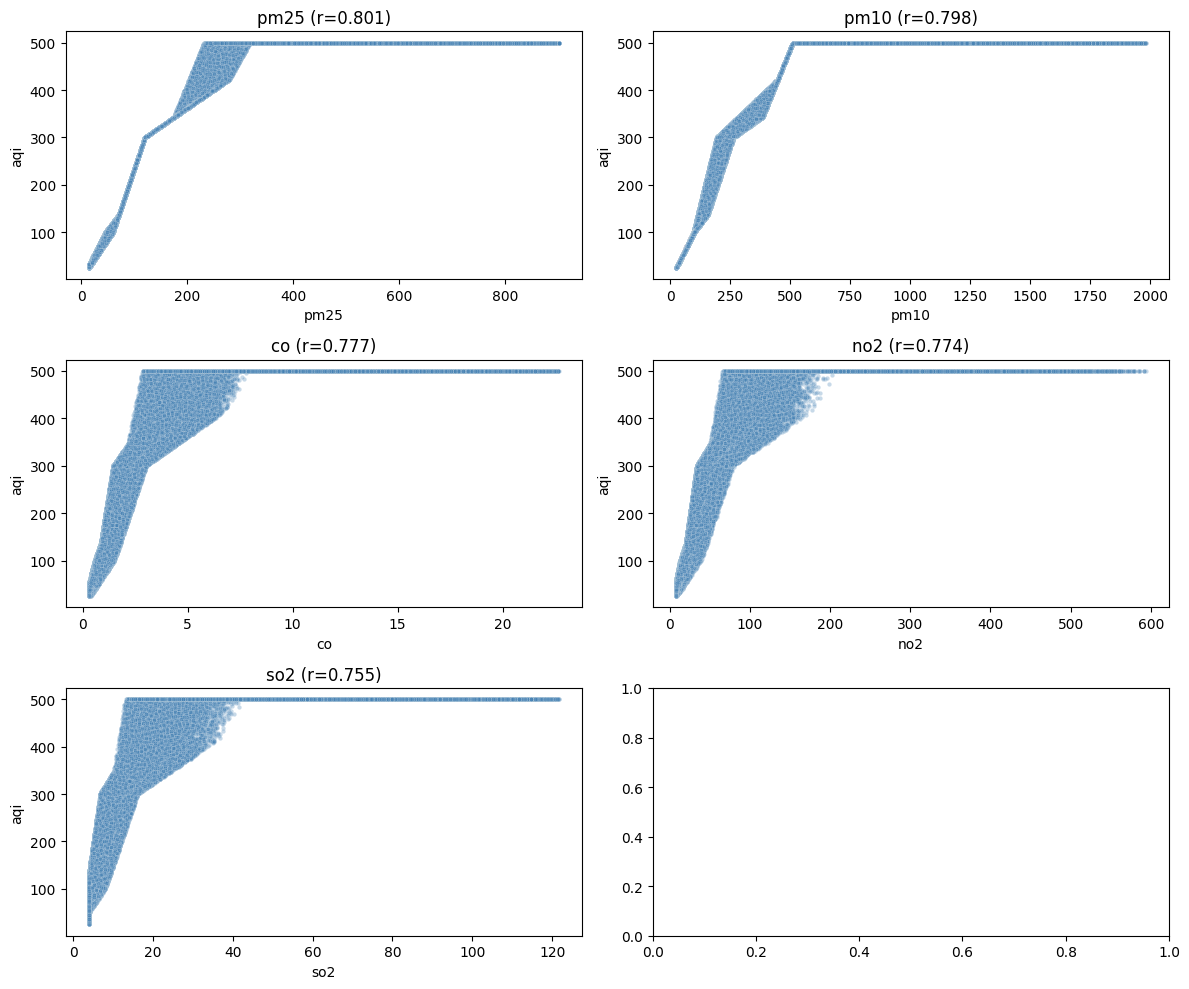

In [6]:
# Correlation with AQI:

import seaborn as sns

corr_num = df[num_cols + ["aqi"]].corr()["aqi"].drop("aqi")

print(corr_num.sort_values(ascending=False))

# Key scatter plots: top features vs aqi
key_features = corr_num.nlargest(5)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (feat, r) in zip(axes, key_features.items()):
    sns.scatterplot(
      data=df,
      x=feat,
      y='aqi',
      alpha=0.3,
        s=10,
        color="steelblue",
        ax=ax
    )
    ax.set_title(f"{feat} (r={r:.3f})")
    # ax.set_xlabel(feat)
    # ax.set_ylabel('Price ($k)')
    # ax.set_title(f'{feat}  (r={r:.3f})')
plt.tight_layout()
plt.show()

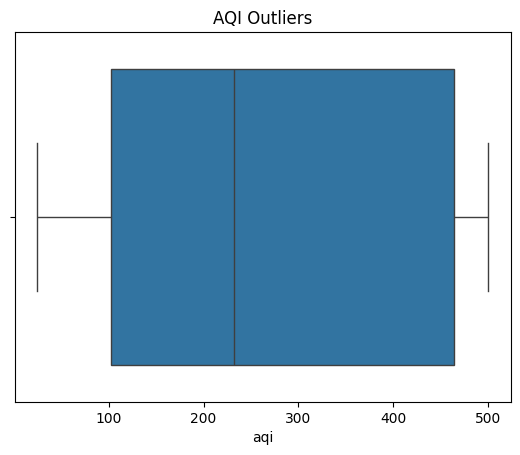

In [7]:
# outliners

sns.boxplot(x=df['aqi'])
plt.title('AQI Outliers')
plt.show()

In [ ]:
# from app.features.preprocessing import load_and_clean, transform_target
# from app.features.feature_engineering import build_feature_pipeline

# df, config = load_and_clean(config_path="../configs/delhi.yaml")
# X, y = transform_target(
#     df,
#     target=config['dataset']['target'],
#     log_transform=config['log_transform_target']
# )
# pipeline = build_feature_pipeline(config)
# X_transformed = pipeline.fit_transform(X)

# print(X_transformed.shape)
# print(f"Target shape: {y.shape}")

print(df.columns.tolist())


(201664, 39)
Target shape: (201664,)
['month', 'day', 'hour', 'day_of_week', 'is_weekend', 'season', 'station', 'latitude', 'longitude', 'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi', 'aqi_capped']
